In [1]:
import pandas as pd
import numpy as np

In [2]:
df1 = pd.read_csv("../data/news_summary.csv", encoding="iso-8859-1")
df2 = pd.read_csv("../data/news_summary_more.csv", encoding="iso-8859-1")

In [3]:
print(df1.columns.tolist())
print(df1["ctext"][0])  # check actual inshorts summary
print("\nWord count of ctext:", len(df1["ctext"][0].split()))
print(df1["text"][0])  # check actual inshorts summary
print("\nWord count of text:", len(df1["text"][0].split()))

['author', 'date', 'headlines', 'read_more', 'text', 'ctext']
The Daman and Diu administration on Wednesday withdrew a circular that asked women staff to tie rakhis on male colleagues after the order triggered a backlash from employees and was ripped apart on social media.The union territory?s administration was forced to retreat within 24 hours of issuing the circular that made it compulsory for its staff to celebrate Rakshabandhan at workplace.?It has been decided to celebrate the festival of Rakshabandhan on August 7. In this connection, all offices/ departments shall remain open and celebrate the festival collectively at a suitable time wherein all the lady staff shall tie rakhis to their colleagues,? the order, issued on August 1 by Gurpreet Singh, deputy secretary (personnel), had said.To ensure that no one skipped office, an attendance report was to be sent to the government the next evening.The two notifications ? one mandating the celebration of Rakshabandhan (left) and the ot

In [4]:
def counttext(row):
    no_text = len(str(row["text"]).split())
    no_ctext = len(str(row["ctext"]).split())
    return no_text, no_ctext

In [5]:
df1.apply(counttext, axis=1)

0       (60, 364)
1       (60, 396)
2       (60, 335)
3       (60, 404)
4       (60, 526)
          ...    
4509    (60, 177)
4510    (60, 140)
4511    (59, 658)
4512    (59, 210)
4513    (60, 259)
Length: 4514, dtype: object

In [7]:
df1.sample(5)

,author,date,headlines,read_more,text,ctext
4344,Prashanti Moktan,"07 Mar 2017,Tuesday",Kapil Sharma to donate his eyes after meeting ...,http://indiatoday.intoday.in/story/kapil-sharm...,Television show host Kapil Sharma has announce...,"Comedian Kapil Sharma, who invited the nationa..."
3378,Prashanti Moktan,"11 May 2017,Thursday",Writer Manto's 105th birth anniversary being o...,http://indiatoday.intoday.in/story/saadat-hasa...,Indo-Pakistani writer and playwright Saadat Ha...,Words don't come easy when it comes to describ...
737,Daisy Mowke,"22 Jul 2017,Saturday",Nolan slams Netflix for not releasing its cont...,http://www.hindustantimes.com/hollywood/dunkir...,Hollywood director Christopher Nolan has slamm...,Filmmaker Christopher Nolan has slammed stream...
3,Sumedha Sehra,"03 Aug 2017,Thursday",Aaj aapne pakad liya: LeT man Dujana before be...,http://indiatoday.intoday.in/story/abu-dujana-...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...
4064,Prashanti Moktan,"26 Mar 2017,Sunday","Sonam to auction her clothes, bags for charity...",http://indiatoday.intoday.in/story/sonam-kapoo...,"As per reports, actress Sonam Kapoor will auct...",Sonam Kapoor is hailed as the diva that made t...


In [8]:
df2.sample(5)

,headlines,text
27103,SC judge AK Goel appointed National Green Trib...,Supreme Court judge Justice Adarsh Kumar Goel ...
62030,N Korea's nuclear tests causing deformed babie...,North Korea's nuclear tests are causing deform...
28589,"Centre wants to divide Hindus and Muslims, say...",Claiming the Central government has no policy ...
84724,Australia won the 1999 World Cup after a tied ...,Australia won the 1999 Cricket World Cup after...
14711,Pune-based startup reports data breach on website,Pune-based startup EarlySalary reported a secu...


In [9]:
df1.shape

(4514, 6)

In [10]:
df2.shape

(98401, 2)

In [11]:
df = df1[["ctext", "text"]].rename(columns={
    "ctext": "article",
    "text":  "summary"
})
print(df.shape)
df.head(5)

(4514, 2)


,article,summary
0,The Daman and Diu administration on Wednesday ...,The Administration of Union Territory Daman an...
1,"From her special numbers to TV?appearances, Bo...",Malaika Arora slammed an Instagram user who tr...
2,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...
3,Lashkar-e-Taiba's Kashmir commander Abu Dujana...,Lashkar-e-Taiba's Kashmir commander Abu Dujana...
4,Hotels in Mumbai and other Indian cities are t...,Hotels in Maharashtra will train their staff t...


In [12]:
print(df.isnull().sum())

article    118
summary      0
dtype: int64


In [13]:
print("before : ",df.shape)
df = df.dropna(subset = ["article" , "summary"])
print("after : ",df.shape)

before :  (4514, 2)
after :  (4396, 2)


In [14]:
df["article_len"] = df["article"].str.split().str.len()
df["summary_len"] = df["summary"].str.split().str.len()

In [15]:
df.sample(10)

,article,summary,article_len,summary_len
859,A south Delhi mall allegedly denied entry to a...,DLF Place Mall in Delhi's Saket on Wednesday r...,380,60
2318,Benghazi?s international airport officially re...,The Benina International Airport reopened on S...,238,60
445,Less than a day after resigning as Bihar chief...,Janata Dal (United) leader Nitish Kumar took o...,3247,60
2137,Demonetisation politics seem to have gone one ...,West Bengal CM Mamata Banerjee on Friday annou...,502,60
209,A 45-year old man in Assam?s in Lakhimpur dist...,A woman in Assam killed her husband for allege...,180,59
3285,WhatsApp is making it easier for people to kee...,Facebook-owned messaging platform WhatsApp has...,203,60
1822,Twinkle Khanna's wit and good looks catapult h...,"According to reports, actor Shahid Kapoor has ...",73,59
3660,Delhi residents will vote in the Municipal Cor...,For the first time in Municipal Corporation of...,573,53
1865,"The other thing Amul is known for, besides mak...",Dairy cooperative Amul has released a new post...,123,53
2993,Lawyers of Calcutta High Court want to give up...,The Calcutta High Court lawyers have written t...,322,59


In [16]:
 df["article_len"].min()

1

In [17]:
print("Before filtering:", df.shape)

df = df[df["article"].str.split().str.len() >= 50]
df = df[df["summary"].str.split().str.len() >= 20]

df = df.reset_index(drop=True)     # reset index after filtering
print("After filtering:", df.shape)

Before filtering: (4396, 4)
After filtering: (4303, 4)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   article      4303 non-null   object
 1   summary      4303 non-null   object
 2   article_len  4303 non-null   int64 
 3   summary_len  4303 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 134.6+ KB


In [19]:
df.describe()

,article_len,summary_len
count,4303.000000,4303.000000
mean,349.739484,58.305833
std,358.496677,2.310484
min,50.000000,44.000000
25%,191.000000,57.000000
50%,287.000000,59.000000
75%,414.000000,60.000000
max,12202.000000,62.000000


In [20]:
import matplotlib.pyplot as plt

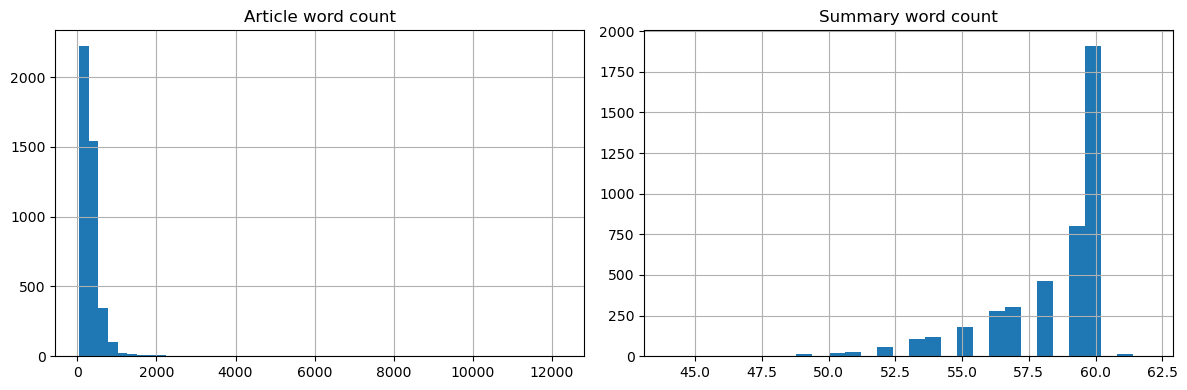

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["article_len"].hist(bins=50, ax=axes[0])
axes[0].set_title("Article word count")
df["summary_len"].hist(bins=30, ax=axes[1])
axes[1].set_title("Summary word count")
plt.tight_layout()
plt.savefig("../data/length_dist.png")
plt.show()

In [23]:
print("Shape:", df.shape)
print("\nSample article:", df["article"][0])
print("\nSample summary:", df["summary"][0])
print("Summary words:", len(df["summary"][0].split()))

Shape: (4303, 4)

Sample article: The Daman and Diu administration on Wednesday withdrew a circular that asked women staff to tie rakhis on male colleagues after the order triggered a backlash from employees and was ripped apart on social media.The union territory?s administration was forced to retreat within 24 hours of issuing the circular that made it compulsory for its staff to celebrate Rakshabandhan at workplace.?It has been decided to celebrate the festival of Rakshabandhan on August 7. In this connection, all offices/ departments shall remain open and celebrate the festival collectively at a suitable time wherein all the lady staff shall tie rakhis to their colleagues,? the order, issued on August 1 by Gurpreet Singh, deputy secretary (personnel), had said.To ensure that no one skipped office, an attendance report was to be sent to the government the next evening.The two notifications ? one mandating the celebration of Rakshabandhan (left) and the other withdrawing the mandate 

In [26]:
df.to_csv("../data/clean_data.csv",index = False)
print("saved!")

saved!


In [25]:
df.to_csv("../data/clean_data_v2.csv", index=False)
print("Saved!")
print("Shape:", df.shape)

Saved!
Shape: (4303, 4)


In [27]:
print(df.columns.tolist())
df.head(3)

['article', 'summary', 'article_len', 'summary_len']


,article,summary,article_len,summary_len
0,The Daman and Diu administration on Wednesday ...,The Administration of Union Territory Daman an...,364,60
1,"From her special numbers to TV?appearances, Bo...",Malaika Arora slammed an Instagram user who tr...,396,60
2,The Indira Gandhi Institute of Medical Science...,The Indira Gandhi Institute of Medical Science...,335,60


In [29]:
df_final = df[["article", "summary"]]
df_final.to_csv("../data/clean_data_v2.csv", index=False)
print("Saved!")
print("Shape:", df_final.shape)

Saved!
Shape: (4303, 2)
